# Optimizer Comparison


Compares PINN optimizer strategies under a fixed training/evaluation setup. The primary comparison uses completed runs with both ID and OOD evaluation; SOAP and the older Adam scheduler batch are retained only as auxiliary context where their run matrix is incomplete or not comparable.

Pipeline: `src/experiments/pipeline/run_optimizer_comparison.py`  
Experiment catalogue: `src/experiments/README.md`  
Outputs: `outputs/optimizer_comparison/`  
Table exports: `results/tables/02_optimizer_comparison/`; scratch exports to `results/data/` are disabled for repository submission.


## Imports


In [1]:
from __future__ import annotations

from pathlib import Path
import sys

REPO_ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from src.visualization.results_helpers import (
    aggregate_mean_sem,
    artifact_path,
    epoch_metrics_path,
    eval_metric,
    load_posthoc_external_eval,
    load_json,
    mean_sem_text,
    overlay_posthoc_external_eval,
    read_epoch_metrics,
    run_dir,
    sem,
    split_metric,
)
from results.notebook_utils import table_dir, write_table, write_numeric_table

from src.visualization.thesis_style import (
    DTU_COLORS,
    NEUTRAL_COLORS,
    adjust_scatter_labels,
    set_thesis_style,
)

set_thesis_style()

## Data Loading


In [2]:
ROOT = Path("../outputs/optimizer_comparison")
EXPORT = Path("data/thesis_02_optimizer_comparison")
# Scratch export directory is intentionally not created for repository submission.
TABLE_EXPORT = table_dir("optimizer_comparison")

ANALYSIS_ORDER = [
    "adam_no_scheduler",
    "adam_scheduler",
    "adam_scheduler_aux",
    "soap",
    "lbfgs",
    "bfgs",
    "ssbfgs",
    "ssbroyden",
    "adam_lbfgs",
    "adam_ssbroyden",
]

LABELS = {
    "adam_no_scheduler": "Adam",
    "adam_scheduler": "Adam + scheduler",
    "adam_scheduler_aux": "Adam + scheduler (OOD-only)",
    "soap": "SOAP",
    "lbfgs": "L-BFGS",
    "bfgs": "BFGS",
    "ssbfgs": "SSBFGS",
    "ssbroyden": "SSBroyden",
    "adam_lbfgs": "Adam -> L-BFGS",
    "adam_ssbroyden": "Adam -> SSBroyden",
}

FAMILY = {
    "adam_no_scheduler": "first-order",
    "adam_scheduler": "first-order",
    "adam_scheduler_aux": "first-order auxiliary",
    "soap": "first-order",
    "lbfgs": "quasi-Newton",
    "bfgs": "quasi-Newton",
    "ssbfgs": "self-scaled quasi-Newton",
    "ssbroyden": "self-scaled quasi-Newton",
    "adam_lbfgs": "hybrid",
    "adam_ssbroyden": "hybrid",
}

FAMILY_COLOR = {
    "first-order": NEUTRAL_COLORS["muted"],
    "first-order auxiliary": DTU_COLORS["grey"],
    "quasi-Newton": DTU_COLORS["green"],
    "self-scaled quasi-Newton": DTU_COLORS["corporate_red"],
    "hybrid": DTU_COLORS["blue"],
}

SELECTED_CONVERGENCE = ["adam_no_scheduler", "adam_scheduler_aux", "lbfgs", "ssbroyden", "adam_ssbroyden"]
AUXILIARY_ANALYSIS_KEYS = {"adam_scheduler_aux", "soap"}
PRIMARY_EXCLUDED_ANALYSIS_KEYS = AUXILIARY_ANALYSIS_KEYS


def as_bool(value, default=False) -> bool:
    if pd.isna(value):
        return default
    if isinstance(value, str):
        return value.strip().lower() in {"true", "1", "yes", "y"}
    return bool(value)


def analysis_key_for(strategy, *, adam_scheduler, has_id_eval) -> str:
    strategy = str(strategy)
    if strategy != "adam":
        return strategy
    scheduler_enabled = as_bool(adam_scheduler, default=False)
    if scheduler_enabled and not bool(has_id_eval):
        return "adam_scheduler_aux"
    if scheduler_enabled:
        return "adam_scheduler"
    return "adam_no_scheduler"


def final_loss_component(metrics: dict | None, split_name: str, component: str) -> float:
    value = ((metrics or {}).get(f"final_{split_name}_losses") or {}).get(component)
    return np.nan if value is None else float(value)


def optimizer_color(key: str) -> str:
    return FAMILY_COLOR.get(FAMILY.get(str(key), "other"), NEUTRAL_COLORS["muted"])


In [3]:
summary_frames = []
summary_keys = set()
manifest_rows = []

for batch_dir in sorted(ROOT.glob("*")):
    if not batch_dir.is_dir():
        continue
    manifest = load_json(batch_dir / "run_manifest.json", default={}) or {}
    artifacts = manifest.get("artifacts", {})
    manifest_runs = manifest.get("runs", [])
    manifest_rows.append({
        "batch": batch_dir.name,
        "strategies": artifacts.get("strategies"),
        "seed_labels": artifacts.get("seed_labels"),
        "total_epochs": artifacts.get("total_epochs"),
        "adam_scheduler": artifacts.get("adam_scheduler"),
        "dataset_reference_id": artifacts.get("dataset_reference_id"),
        "id_eval_id": artifacts.get("id_eval_id"),
        "ood_eval_id": artifacts.get("ood_eval_id"),
        "summary_present": (batch_dir / "summary.csv").exists(),
        "manifest_runs": len(manifest_runs),
        "manifest_completed": sum(1 for run in manifest_runs if run.get("status") == "completed"),
    })

    summary_path = batch_dir / "summary.csv"
    if summary_path.exists():
        frame = pd.read_csv(summary_path)
        frame["batch"] = batch_dir.name
        for col, value in {
            "total_epochs": artifacts.get("total_epochs"),
            "adam_scheduler": artifacts.get("adam_scheduler"),
            "dataset_reference_id": artifacts.get("dataset_reference_id"),
            "id_eval_id": artifacts.get("id_eval_id"),
            "ood_eval_id": artifacts.get("ood_eval_id"),
        }.items():
            if col not in frame.columns or frame[col].isna().all():
                frame[col] = value
        summary_frames.append(frame)
        for _, row in frame.iterrows():
            summary_keys.add((batch_dir.name, row.get("run_name")))

runs = pd.concat(summary_frames, ignore_index=True, sort=False) if summary_frames else pd.DataFrame()

extra_rows = []
for batch_dir in sorted(ROOT.glob("*")):
    if not batch_dir.is_dir():
        continue
    manifest = load_json(batch_dir / "run_manifest.json", default={}) or {}
    artifacts = manifest.get("artifacts", {})
    for run in manifest.get("runs", []):
        key = (batch_dir.name, run.get("run_name"))
        if key in summary_keys:
            continue
        metrics = load_json(artifact_path(ROOT, batch_dir.name, run.get("run_name"), "metrics.json"), default=None)
        timings = load_json(artifact_path(ROOT, batch_dir.name, run.get("run_name"), "timings.json"), default={}) or {}
        if metrics is None:
            continue
        extra_rows.append({
            "batch": batch_dir.name,
            "run_name": run.get("run_name"),
            "strategy": run.get("strategy"),
            "strategy_group": run.get("strategy_group"),
            "optimizer": run.get("optimizer"),
            "training_strategy": run.get("training_strategy"),
            "seed_label": run.get("seed_label"),
            "seed_value": run.get("seed_value"),
            "total_epochs": artifacts.get("total_epochs"),
            "adam_scheduler": artifacts.get("adam_scheduler"),
            "dataset_reference_id": artifacts.get("dataset_reference_id"),
            "id_eval_id": artifacts.get("id_eval_id"),
            "ood_eval_id": artifacts.get("ood_eval_id"),
            "status": run.get("status"),
            "return_code": run.get("return_code"),
            "final_test_mse": split_metric(metrics, "final", "test", "mse"),
            "final_test_mae": split_metric(metrics, "final", "test", "mae"),
            "total_seconds": timings.get("total_seconds"),
            "training_seconds": timings.get("training_seconds"),
        })

if extra_rows:
    runs = pd.concat([runs, pd.DataFrame(extra_rows)], ignore_index=True, sort=False)


In [4]:
recovered_rows = []
for _, source in runs.iterrows():
    batch = source.get("batch")
    run_name = source.get("run_name")
    metrics = load_json(artifact_path(ROOT, batch, run_name, "metrics.json"), default={}) or {}
    timings = load_json(artifact_path(ROOT, batch, run_name, "timings.json"), default={}) or {}
    row = source.to_dict()

    for eval_name in ("id", "ood"):
        for metric in ("mse", "rmse", "mae"):
            best_col = f"best_{eval_name}_eval_{metric}"
            final_col = f"final_{eval_name}_eval_{metric}"
            best_value = eval_metric(metrics, "best", eval_name, metric)
            final_value = eval_metric(metrics, "final", eval_name, metric)
            fallback_best = row.get(f"best_checkpoint_{eval_name}_eval_{metric}", np.nan)
            fallback_final = row.get(f"{eval_name}_eval_{metric}", np.nan)

            if pd.notna(best_value):
                row[best_col] = best_value
                row[f"metric_source_best_{eval_name}"] = "metrics_json_best_checkpoint"
            elif pd.notna(fallback_best):
                row[best_col] = fallback_best
                row[f"metric_source_best_{eval_name}"] = "summary_best_checkpoint"
            elif pd.notna(final_value):
                row[best_col] = final_value
                row[f"metric_source_best_{eval_name}"] = "metrics_json_final_fallback"
            elif pd.notna(fallback_final):
                row[best_col] = fallback_final
                row[f"metric_source_best_{eval_name}"] = "summary_final_fallback"
            else:
                row[best_col] = np.nan
                row[f"metric_source_best_{eval_name}"] = "missing"

            row[final_col] = final_value if pd.notna(final_value) else fallback_final

    for split in ("train", "val", "test"):
        for metric in ("mse", "rmse", "mae"):
            row[f"best_{split}_{metric}"] = split_metric(metrics, "best", split, metric)
            final_col = f"final_{split}_{metric}"
            if pd.isna(row.get(final_col, np.nan)):
                row[final_col] = split_metric(metrics, "final", split, metric)

    for component in ("total", "data", "dt", "physics", "ic"):
        row[f"final_train_{component}_loss"] = row.get(
            f"final_train_{component}_loss",
            final_loss_component(metrics, "train", component),
        )
        row[f"final_val_{component}_loss"] = final_loss_component(metrics, "val", component)
        row[f"final_test_{component}_loss"] = final_loss_component(metrics, "test", component)

    row["total_seconds"] = row.get("total_seconds", np.nan) if pd.notna(row.get("total_seconds", np.nan)) else timings.get("total_seconds")
    row["training_seconds"] = row.get("training_seconds", np.nan) if pd.notna(row.get("training_seconds", np.nan)) else timings.get("training_seconds")
    row["epoch_metrics_local_path"] = str(epoch_metrics_path(ROOT, batch, run_name))
    row["epoch_metrics_exists"] = epoch_metrics_path(ROOT, batch, run_name).exists()
    row["has_id_eval"] = pd.notna(row.get("best_id_eval_mse", np.nan))
    row["has_ood_eval"] = pd.notna(row.get("best_ood_eval_mse", np.nan))
    row["analysis_key"] = analysis_key_for(row.get("strategy"), adam_scheduler=row.get("adam_scheduler", False), has_id_eval=row["has_id_eval"])
    row["optimizer_label"] = LABELS.get(row["analysis_key"], str(row.get("strategy")))
    row["optimizer_family"] = FAMILY.get(row["analysis_key"], "other")
    row["is_auxiliary"] = str(row["analysis_key"]) in AUXILIARY_ANALYSIS_KEYS
    row["is_primary"] = (
        str(row.get("status")) == "completed"
        and bool(row["has_id_eval"])
        and bool(row["has_ood_eval"])
        and str(row["analysis_key"]) not in PRIMARY_EXCLUDED_ANALYSIS_KEYS
    )
    recovered_rows.append(row)

runs = pd.DataFrame(recovered_rows)
posthoc_eval = load_posthoc_external_eval(ROOT)
if posthoc_eval.empty:
    raise FileNotFoundError(f"No posthoc evaluation results found under {ROOT}")
runs = overlay_posthoc_external_eval(runs, posthoc_eval, on=("batch", "run_name"))
runs["has_posthoc_eval"] = runs.get("posthoc_status", pd.Series(index=runs.index, dtype=object)).eq("completed")
for eval_name in ("id", "ood"):
    source_col = f"metric_source_best_{eval_name}"
    runs.loc[runs["has_posthoc_eval"], source_col] = "posthoc_checkpoint"
runs["external_eval_source"] = np.where(runs["has_posthoc_eval"], "posthoc_checkpoint", "training_run_metrics")
runs["has_id_eval"] = pd.to_numeric(runs.get("best_id_eval_mse", np.nan), errors="coerce").notna()
runs["has_ood_eval"] = pd.to_numeric(runs.get("best_ood_eval_mse", np.nan), errors="coerce").notna()
runs["analysis_key"] = runs.apply(
    lambda row: analysis_key_for(row.get("strategy"), adam_scheduler=row.get("adam_scheduler", False), has_id_eval=row["has_id_eval"]),
    axis=1,
)
runs["optimizer_label"] = runs["analysis_key"].astype(str).map(lambda key: LABELS.get(key, key))
runs["optimizer_family"] = runs["analysis_key"].astype(str).map(lambda key: FAMILY.get(key, "other"))
runs["is_auxiliary"] = runs["analysis_key"].astype(str).isin(AUXILIARY_ANALYSIS_KEYS)
runs["is_primary"] = (
    runs["status"].astype(str).eq("completed")
    & runs["has_posthoc_eval"]
    & runs["has_id_eval"]
    & runs["has_ood_eval"]
    & ~runs["analysis_key"].astype(str).isin(PRIMARY_EXCLUDED_ANALYSIS_KEYS)
)
runs["analysis_key"] = pd.Categorical(runs["analysis_key"], categories=ANALYSIS_ORDER, ordered=True)
runs = runs.sort_values(["analysis_key", "seed_label", "batch", "run_name"]).reset_index(drop=True)
batches = pd.DataFrame(manifest_rows)

# Scratch export disabled for repository submission; keep derived data in memory.
# runs.to_csv(EXPORT / "runs.csv", index=False)
# batches.to_csv(EXPORT / "batches.csv", index=False)

print(f"runs: {runs.shape}")
print(f"batches: {batches.shape}")
display(runs[["batch", "run_name", "analysis_key", "seed_label", "status", "external_eval_source", "posthoc_ood_mode", "has_id_eval", "has_ood_eval", "best_id_eval_mse", "best_ood_eval_mse", "total_seconds"]])


runs: (26, 161)
batches: (5, 11)


,batch,run_name,analysis_key,seed_label,status,external_eval_source,posthoc_ood_mode,has_id_eval,has_ood_eval,best_id_eval_mse,best_ood_eval_mse,total_seconds
0,adam_no_scheduler_s01_s03,adam_s01,adam_no_scheduler,s01,completed,posthoc_checkpoint,exclusive,True,True,3.197023e-06,0.028393,7159.828896
1,adam_no_scheduler_s01_s03,adam_s02,adam_no_scheduler,s02,completed,posthoc_checkpoint,exclusive,True,True,2.522312e-06,0.026916,7043.895155
2,adam_no_scheduler_s01_s03,adam_s03,adam_no_scheduler,s03,completed,posthoc_checkpoint,exclusive,True,True,3.663351e-06,0.027490,7384.020925
3,20260503_151752,adam_s01,adam_scheduler_aux,s01,completed,training_run_metrics,NaN,False,True,NaN,0.016615,27468.312491
4,20260503_151752,adam_s02,adam_scheduler_aux,s02,completed,training_run_metrics,NaN,False,True,NaN,0.015799,27354.937513
5,20260503_151752,adam_s03,adam_scheduler_aux,s03,completed,training_run_metrics,NaN,False,True,NaN,0.022343,26998.798513
6,20260514_070505,soap_s02,soap,s02,completed,training_run_metrics,NaN,True,True,1.787477e-04,0.016585,8573.946933
7,20260516_040650,soap_s03,soap,s03,completed,training_run_metrics,NaN,True,True,1.369813e-04,0.021922,8405.274166
8,20260513_062330,lbfgs_s01,lbfgs,s01,completed,posthoc_checkpoint,exclusive,True,True,3.901401e-06,0.003205,949.014596
9,20260514_070505,lbfgs_s02,lbfgs,s02,completed,posthoc_checkpoint,exclusive,True,True,2.604820e-06,0.002709,974.203795


## Completeness


In [5]:
expected_seeds = {key: {"s01", "s02", "s03"} for key in ANALYSIS_ORDER}
completion_rows = []
for key in [k for k in ANALYSIS_ORDER if k in set(runs["analysis_key"].astype(str))]:
    sub = runs[runs["analysis_key"].astype(str) == key]
    available = set(sub["seed_label"].dropna().astype(str))
    expected = expected_seeds.get(key, {"s01", "s02", "s03"})
    notes = []
    missing = sorted(expected - available)
    if missing:
        notes.append("missing " + ",".join(missing))
    if not bool(sub["has_id_eval"].all()):
        notes.append("ID eval incomplete")
    if not bool(sub["has_ood_eval"].all()):
        notes.append("OOD eval incomplete")
    if key == "adam_scheduler_aux":
        notes.append("old scheduler batch; OOD-only auxiliary")
    if key == "soap":
        notes.append("auxiliary only; incomplete seed matrix")
    completion_rows.append({
        "optimizer": LABELS.get(key, key),
        "analysis_key": key,
        "family": FAMILY.get(key, "other"),
        "expected_seeds": ",".join(sorted(expected)),
        "available_seeds": ",".join(sorted(available)),
        "n_runs": int(len(sub)),
        "n_completed": int((sub["status"] == "completed").sum()),
        "n_id_eval": int(sub["has_id_eval"].sum()),
        "n_ood_eval": int(sub["has_ood_eval"].sum()),
        "notes": "; ".join(notes),
    })

completion = pd.DataFrame(completion_rows)
# Scratch export disabled for repository submission; keep derived data in memory.
# completion.to_csv(EXPORT / "completion.csv", index=False)
primary = runs[runs["is_primary"]].copy()
auxiliary = runs[~runs["is_primary"]].copy()
# Scratch export disabled for repository submission; keep derived data in memory.
# primary.to_csv(EXPORT / "primary_runs.csv", index=False)
# auxiliary.to_csv(EXPORT / "auxiliary_runs.csv", index=False)

display(completion)
print(f"primary runs: {primary.shape}")
print(f"auxiliary runs: {auxiliary.shape}")


,optimizer,analysis_key,family,expected_seeds,available_seeds,n_runs,n_completed,n_id_eval,n_ood_eval,notes
0,Adam,adam_no_scheduler,first-order,"s01,s02,s03","s01,s02,s03",3,3,3,3,
1,Adam + scheduler (OOD-only),adam_scheduler_aux,first-order auxiliary,"s01,s02,s03","s01,s02,s03",3,3,0,3,ID eval incomplete; old scheduler batch; OOD-o...
2,SOAP,soap,first-order,"s01,s02,s03","s02,s03",2,2,2,2,missing s01; auxiliary only; incomplete seed m...
3,L-BFGS,lbfgs,quasi-Newton,"s01,s02,s03","s01,s02,s03",3,3,3,3,
4,BFGS,bfgs,quasi-Newton,"s01,s02,s03","s01,s02,s03",3,3,3,3,
5,SSBFGS,ssbfgs,self-scaled quasi-Newton,"s01,s02,s03","s01,s02,s03",3,3,3,3,
6,SSBroyden,ssbroyden,self-scaled quasi-Newton,"s01,s02,s03","s01,s02,s03",3,3,3,3,
7,Adam -> L-BFGS,adam_lbfgs,hybrid,"s01,s02,s03","s01,s02,s03",3,3,3,3,
8,Adam -> SSBroyden,adam_ssbroyden,hybrid,"s01,s02,s03","s01,s02,s03",3,3,3,3,


primary runs: (21, 161)
auxiliary runs: (5, 161)


## Thesis Summary Table


In [6]:
POSTHOC_SUMMARY_METRICS = [
    "best_id_eval_mse", "best_id_eval_rmse", "best_id_eval_mae", "best_id_eval_max_abs_error",
    "best_id_eval_trajectory_mse_mean", "best_id_eval_trajectory_mse_p90",
    "best_id_eval_trajectory_mse_p95", "best_id_eval_trajectory_mse_max",
    "best_id_eval_trajectory_rmse_mean", "best_id_eval_trajectory_rmse_p90",
    "best_id_eval_trajectory_rmse_p95", "best_id_eval_trajectory_rmse_max",
    "best_id_eval_trajectory_max_abs_error_mean",
    "best_id_eval_trajectory_max_abs_error_p95",
    "best_id_eval_trajectory_max_abs_error_max",
    "best_id_eval_n_rows", "best_id_eval_n_trajectories",
    "best_ood_eval_mse", "best_ood_eval_rmse", "best_ood_eval_mae", "best_ood_eval_max_abs_error",
    "best_ood_eval_trajectory_mse_mean", "best_ood_eval_trajectory_mse_p90",
    "best_ood_eval_trajectory_mse_p95", "best_ood_eval_trajectory_mse_max",
    "best_ood_eval_trajectory_rmse_mean", "best_ood_eval_trajectory_rmse_p90",
    "best_ood_eval_trajectory_rmse_p95", "best_ood_eval_trajectory_rmse_max",
    "best_ood_eval_trajectory_max_abs_error_mean",
    "best_ood_eval_trajectory_max_abs_error_p95",
    "best_ood_eval_trajectory_max_abs_error_max",
    "best_ood_eval_n_rows_before_filter", "best_ood_eval_n_trajectories_before_filter",
    "best_ood_eval_n_rows", "best_ood_eval_n_trajectories",
]
SUMMARY_METRICS = POSTHOC_SUMMARY_METRICS + ["final_test_mse", "total_seconds", "training_seconds"]
POSTHOC_METRIC_LABELS = [
    ("best_id_eval_mse", "ID MSE"),
    ("best_id_eval_rmse", "ID RMSE"),
    ("best_id_eval_mae", "ID MAE"),
    ("best_id_eval_max_abs_error", "ID max abs error"),
    ("best_id_eval_trajectory_mse_mean", "ID trajectory MSE mean"),
    ("best_id_eval_trajectory_mse_p90", "ID trajectory MSE p90"),
    ("best_id_eval_trajectory_mse_p95", "ID trajectory MSE p95"),
    ("best_id_eval_trajectory_mse_max", "ID trajectory MSE max"),
    ("best_id_eval_trajectory_rmse_mean", "ID trajectory RMSE mean"),
    ("best_id_eval_trajectory_rmse_p90", "ID trajectory RMSE p90"),
    ("best_id_eval_trajectory_rmse_p95", "ID trajectory RMSE p95"),
    ("best_id_eval_trajectory_rmse_max", "ID trajectory RMSE max"),
    ("best_id_eval_trajectory_max_abs_error_mean", "ID trajectory max abs error mean"),
    ("best_id_eval_trajectory_max_abs_error_p95", "ID trajectory max abs error p95"),
    ("best_id_eval_trajectory_max_abs_error_max", "ID trajectory max abs error max"),
    ("best_id_eval_n_rows", "ID rows"),
    ("best_id_eval_n_trajectories", "ID trajectories"),
    ("best_ood_eval_mse", "OOD MSE"),
    ("best_ood_eval_rmse", "OOD RMSE"),
    ("best_ood_eval_mae", "OOD MAE"),
    ("best_ood_eval_max_abs_error", "OOD max abs error"),
    ("best_ood_eval_trajectory_mse_mean", "OOD trajectory MSE mean"),
    ("best_ood_eval_trajectory_mse_p90", "OOD trajectory MSE p90"),
    ("best_ood_eval_trajectory_mse_p95", "OOD trajectory MSE p95"),
    ("best_ood_eval_trajectory_mse_max", "OOD trajectory MSE max"),
    ("best_ood_eval_trajectory_rmse_mean", "OOD trajectory RMSE mean"),
    ("best_ood_eval_trajectory_rmse_p90", "OOD trajectory RMSE p90"),
    ("best_ood_eval_trajectory_rmse_p95", "OOD trajectory RMSE p95"),
    ("best_ood_eval_trajectory_rmse_max", "OOD trajectory RMSE max"),
    ("best_ood_eval_trajectory_max_abs_error_mean", "OOD trajectory max abs error mean"),
    ("best_ood_eval_trajectory_max_abs_error_p95", "OOD trajectory max abs error p95"),
    ("best_ood_eval_trajectory_max_abs_error_max", "OOD trajectory max abs error max"),
    ("best_ood_eval_n_rows_before_filter", "OOD rows before filter"),
    ("best_ood_eval_n_trajectories_before_filter", "OOD trajectories before filter"),
    ("best_ood_eval_n_rows", "OOD rows"),
    ("best_ood_eval_n_trajectories", "OOD trajectories"),
]
POSTHOC_COUNT_METRICS = {
    "best_id_eval_n_rows", "best_id_eval_n_trajectories",
    "best_ood_eval_n_rows_before_filter", "best_ood_eval_n_trajectories_before_filter",
    "best_ood_eval_n_rows", "best_ood_eval_n_trajectories",
}

primary_agg = aggregate_mean_sem(
    primary,
    group_cols="analysis_key",
    metrics=SUMMARY_METRICS,
    seed_col="seed_label",
    run_col="run_name",
    order_col="analysis_key",
    order=ANALYSIS_ORDER,
)
aux_agg = aggregate_mean_sem(
    auxiliary[auxiliary["analysis_key"].astype(str) == "adam_scheduler_aux"],
    group_cols="analysis_key",
    metrics=SUMMARY_METRICS,
    seed_col="seed_label",
    run_col="run_name",
    order_col="analysis_key",
    order=ANALYSIS_ORDER,
)
soap_agg = aggregate_mean_sem(
    auxiliary[auxiliary["analysis_key"].astype(str) == "soap"],
    group_cols="analysis_key",
    metrics=SUMMARY_METRICS,
    seed_col="seed_label",
    run_col="run_name",
    order_col="analysis_key",
    order=ANALYSIS_ORDER,
)

write_numeric_table(primary_agg, "optimizer_comparison")
# Scratch export disabled for repository submission; keep derived data in memory.
# aux_agg.to_csv(EXPORT / "summary_table_auxiliary_numeric.csv", index=False)
# soap_agg.to_csv(EXPORT / "summary_table_soap_auxiliary_numeric.csv", index=False)

def metric_text(row: pd.Series, metric: str, *, decimals: int = 2, scientific: bool = True) -> str:
    if pd.isna(row.get(f"{metric}_mean")) and pd.isna(row.get(f"{metric}_sem")):
        return "n/a"
    return mean_sem_text(row, metric, decimals=decimals, scientific=scientific)


def summary_table(agg: pd.DataFrame) -> pd.DataFrame:
    if agg.empty:
        return pd.DataFrame()
    columns = {
        "optimizer": agg["analysis_key"].astype(str).map(LABELS),
        "family": agg["analysis_key"].astype(str).map(FAMILY),
        "seeds": agg["seeds"],
    }
    for metric, label in POSTHOC_METRIC_LABELS:
        if metric in POSTHOC_COUNT_METRICS:
            columns[label] = agg.apply(
                lambda row, metric=metric: metric_text(row, metric, decimals=0, scientific=False), axis=1
            )
        else:
            columns[label] = agg.apply(lambda row, metric=metric: metric_text(row, metric, decimals=2), axis=1)
    columns["test MSE"] = agg.apply(lambda row: metric_text(row, "final_test_mse", decimals=2), axis=1)
    columns["total time [s]"] = agg.apply(
        lambda row: metric_text(row, "total_seconds", decimals=1, scientific=False), axis=1
    )
    columns["training time [s]"] = agg.apply(
        lambda row: metric_text(row, "training_seconds", decimals=1, scientific=False), axis=1
    )
    return pd.DataFrame(columns)

primary_table = summary_table(primary_agg)
aux_table = summary_table(aux_agg)
soap_table = summary_table(soap_agg)
write_table(primary_table, "optimizer_comparison")
# Scratch export disabled for repository submission; keep derived data in memory.
# aux_table.to_csv(EXPORT / "summary_table_auxiliary.csv", index=False)
# soap_table.to_csv(EXPORT / "summary_table_soap_auxiliary.csv", index=False)

display(primary_table)
if not soap_table.empty:
    print("Auxiliary SOAP context")
    display(soap_table)


,optimizer,family,seeds,ID MSE,ID RMSE,ID MAE,ID max abs error,ID trajectory MSE mean,ID trajectory MSE p90,ID trajectory MSE p95,...,OOD trajectory max abs error mean,OOD trajectory max abs error p95,OOD trajectory max abs error max,OOD rows before filter,OOD trajectories before filter,OOD rows,OOD trajectories,test MSE,total time [s],training time [s]
0,Adam,first-order,"s01,s02,s03",3.13e-06 +/- 3.31e-07,1.76e-03 +/- 9.49e-05,1.08e-03 +/- 7.35e-05,2.64e-02 +/- 8.46e-04,3.13e-06 +/- 3.31e-07,6.29e-06 +/- 5.32e-07,8.10e-06 +/- 8.26e-07,...,1.90e-01 +/- 3.02e-03,8.38e-01 +/- 1.25e-02,1.21e+00 +/- 5.60e-02,409409 +/- 0,409 +/- 0,368368 +/- 0,368 +/- 0,6.07e-06 +/- 8.77e-07,7195.9 +/- 99.8,7188.0 +/- 100.4
1,L-BFGS,quasi-Newton,"s01,s02,s03",2.94e-06 +/- 4.89e-07,1.70e-03 +/- 1.39e-04,1.02e-03 +/- 9.18e-05,2.85e-02 +/- 2.91e-03,2.94e-06 +/- 4.89e-07,5.48e-06 +/- 7.68e-07,8.31e-06 +/- 1.54e-06,...,6.88e-02 +/- 2.50e-03,3.13e-01 +/- 8.44e-03,1.03e+00 +/- 5.16e-02,409409 +/- 0,409 +/- 0,368368 +/- 0,368 +/- 0,4.57e-06 +/- 7.13e-07,942.4 +/- 20.5,938.2 +/- 20.5
2,BFGS,quasi-Newton,"s01,s02,s03",1.27e-07 +/- 4.75e-09,3.57e-04 +/- 6.62e-06,2.06e-04 +/- 5.74e-06,9.41e-03 +/- 8.27e-04,1.27e-07 +/- 4.75e-09,2.17e-07 +/- 1.55e-08,3.27e-07 +/- 1.03e-08,...,2.87e-02 +/- 1.56e-04,1.33e-01 +/- 3.42e-03,7.61e-01 +/- 2.03e-02,409409 +/- 0,409 +/- 0,368368 +/- 0,368 +/- 0,1.87e-07 +/- 4.13e-09,3384.5 +/- 145.4,3379.0 +/- 145.2
3,SSBFGS,self-scaled quasi-Newton,"s01,s02,s03",2.77e-08 +/- 1.16e-10,1.66e-04 +/- 3.49e-07,7.77e-05 +/- 8.85e-07,2.06e-03 +/- 9.18e-05,2.77e-08 +/- 1.16e-10,6.91e-08 +/- 1.47e-10,8.79e-08 +/- 6.44e-10,...,1.40e-02 +/- 1.98e-03,6.58e-02 +/- 7.68e-03,4.59e-01 +/- 1.75e-01,409409 +/- 0,409 +/- 0,368368 +/- 0,368 +/- 0,3.46e-08 +/- 8.67e-10,3387.6 +/- 27.3,3382.9 +/- 27.1
4,SSBroyden,self-scaled quasi-Newton,"s01,s02,s03",2.37e-08 +/- 9.27e-11,1.54e-04 +/- 3.01e-07,5.95e-05 +/- 3.19e-07,1.79e-03 +/- 5.53e-05,2.37e-08 +/- 9.27e-11,6.38e-08 +/- 3.00e-10,8.06e-08 +/- 1.98e-10,...,1.12e-02 +/- 8.14e-04,5.10e-02 +/- 3.01e-03,4.76e-01 +/- 4.44e-02,409409 +/- 0,409 +/- 0,368368 +/- 0,368 +/- 0,2.83e-08 +/- 1.11e-10,1190.8 +/- 1.9,1186.3 +/- 2.0
5,Adam -> L-BFGS,hybrid,"s01,s02,s03",2.97e-06 +/- 4.97e-07,1.71e-03 +/- 1.40e-04,1.12e-03 +/- 9.07e-05,2.72e-02 +/- 2.67e-03,2.97e-06 +/- 4.97e-07,5.22e-06 +/- 7.76e-07,7.00e-06 +/- 9.25e-07,...,1.67e-01 +/- 4.68e-03,7.69e-01 +/- 2.40e-02,1.26e+00 +/- 1.71e-02,409409 +/- 0,409 +/- 0,368368 +/- 0,368 +/- 0,3.91e-06 +/- 3.91e-07,1198.7 +/- 3.4,1194.1 +/- 3.5
6,Adam -> SSBroyden,hybrid,"s01,s02,s03",2.35e-08 +/- 1.58e-11,1.53e-04 +/- 5.15e-08,5.90e-05 +/- 2.09e-07,1.78e-03 +/- 2.68e-05,2.35e-08 +/- 1.58e-11,6.36e-08 +/- 9.60e-11,8.00e-08 +/- 1.61e-10,...,2.00e-02 +/- 8.58e-04,1.01e-01 +/- 8.52e-03,6.43e-01 +/- 3.59e-02,409409 +/- 0,409 +/- 0,368368 +/- 0,368 +/- 0,2.79e-08 +/- 1.00e-10,1777.8 +/- 4.8,1773.5 +/- 4.7


Auxiliary SOAP context


,optimizer,family,seeds,ID MSE,ID RMSE,ID MAE,ID max abs error,ID trajectory MSE mean,ID trajectory MSE p90,ID trajectory MSE p95,...,OOD trajectory max abs error mean,OOD trajectory max abs error p95,OOD trajectory max abs error max,OOD rows before filter,OOD trajectories before filter,OOD rows,OOD trajectories,test MSE,total time [s],training time [s]
0,SOAP,first-order,"s02,s03",1.58e-04 +/- 2.09e-05,1.25e-02 +/- 8.33e-04,9.10e-03 +/- 1.61e-04,n/a,n/a,n/a,n/a,...,n/a,n/a,n/a,n/a,n/a,n/a,n/a,3.67e-04 +/- 9.03e-05,8489.6 +/- 84.3,8466.6 +/- 89.4


## Accuracy And Runtime


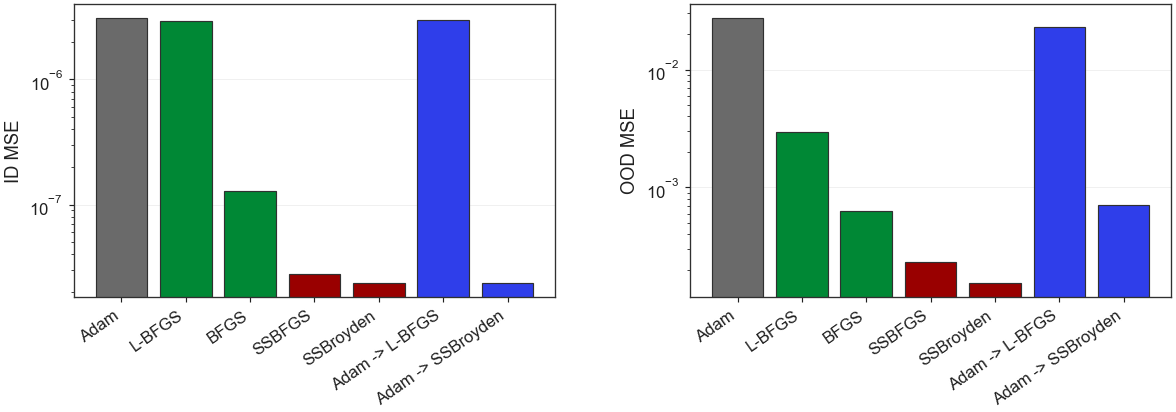

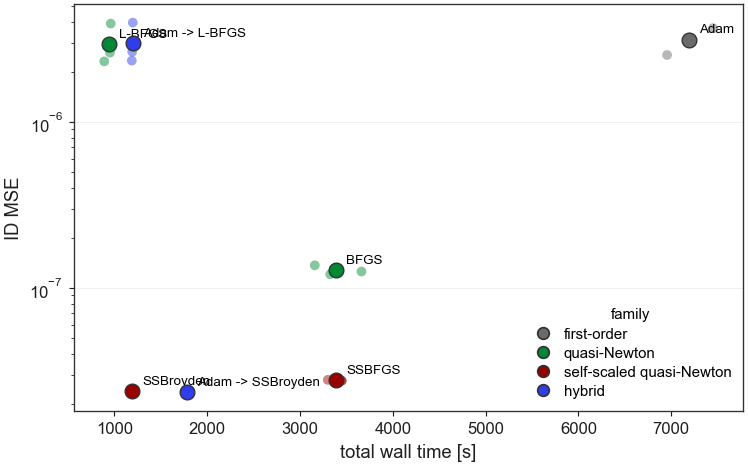

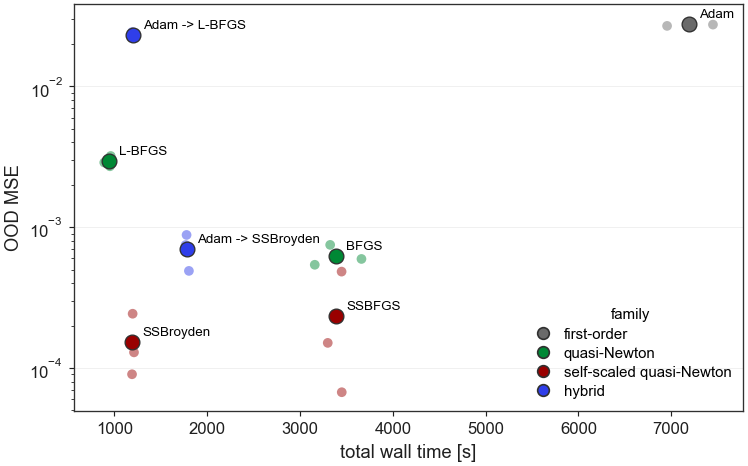

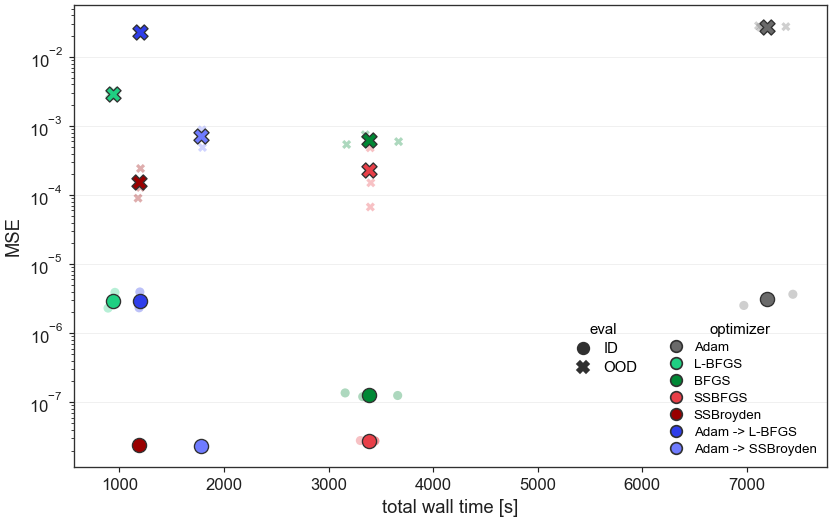

In [7]:
plot_agg = primary_agg.copy()

fig, axes = plt.subplots(1, 2, figsize=(11.8, 4.2), sharex=False)
for ax, metric, ylabel in [
    (axes[0], "best_id_eval_mse", "ID MSE"),
    (axes[1], "best_ood_eval_mse", "OOD MSE"),
]:
    x = np.arange(len(plot_agg))
    colors = [optimizer_color(key) for key in plot_agg["analysis_key"].astype(str)]
    ax.bar(
        x,
        plot_agg[f"{metric}_mean"],
        color=colors,
        edgecolor=NEUTRAL_COLORS["axis"],
        linewidth=0.7,
    )
    ax.set_xticks(x)
    ax.set_xticklabels([LABELS.get(str(key), str(key)) for key in plot_agg["analysis_key"]], rotation=35, ha="right")
    ax.set_yscale("log")
    ax.set_ylabel(ylabel)
    ax.grid(True, axis="y", alpha=0.45)
    ax.grid(False, axis="x")
fig.subplots_adjust(wspace=0.28, bottom=0.30)
# Figure export disabled for repository submission; keep plot inline.
# fig.savefig(EXPORT / "optimizer_id_ood_mse.png", dpi=300, bbox_inches="tight")
plt.show()


def cost_accuracy_scatter(metric: str, ylabel: str, filename: str) -> None:
    fig, ax = plt.subplots(figsize=(7.2, 4.4))
    rng = np.random.default_rng(42)
    texts = []
    for _, row in plot_agg.iterrows():
        key = str(row["analysis_key"])
        color = optimizer_color(key)
        run_sub = primary[primary["analysis_key"].astype(str) == key].copy()
        run_sub["total_seconds"] = pd.to_numeric(run_sub["total_seconds"], errors="coerce")
        run_sub[metric] = pd.to_numeric(run_sub[metric], errors="coerce")
        run_sub = run_sub.dropna(subset=["total_seconds", metric])
        if not run_sub.empty:
            jitter = rng.normal(0.0, 0.012, size=len(run_sub))
            ax.scatter(
                run_sub["total_seconds"] * (1.0 + jitter),
                run_sub[metric],
                s=34,
                color=color,
                alpha=0.48,
                edgecolor="none",
                zorder=2,
            )
        ax.scatter(
            row["total_seconds_mean"],
            row[f"{metric}_mean"],
            s=78,
            color=color,
            edgecolor=NEUTRAL_COLORS["axis"],
            linewidth=0.8,
            zorder=4,
        )
        t = ax.annotate(
            LABELS.get(key, key),
            (row["total_seconds_mean"], row[f"{metric}_mean"]),
            textcoords="offset points",
            xytext=(6, 4),
            fontsize=8,
        )
        texts.append(t)

    family_handles = [
        plt.Line2D([0], [0], marker="o", color="w", label=family, markerfacecolor=color, markeredgecolor=NEUTRAL_COLORS["axis"], markersize=7)
        for family, color in FAMILY_COLOR.items()
        if family != "first-order auxiliary"
    ]
    ax.legend(handles=family_handles, title="family", loc="best")
    ax.set_yscale("log")
    ax.set_xlabel("total wall time [s]")
    ax.set_ylabel(ylabel)
    ax.grid(True, axis="y", alpha=0.45)
    ax.grid(False, axis="x")
    # Must be called after all axis setup (scale, legend, limits) so adjustText
    # operates in the final display coordinate space.
    # adjust_scatter_labels(texts, ax=ax)
    # Figure export disabled for repository submission; keep plot inline.
    # fig.savefig(EXPORT / filename, dpi=300, bbox_inches="tight")
    plt.show()


cost_accuracy_scatter("best_id_eval_mse", "ID MSE", "optimizer_cost_accuracy_id_mse_with_runs.png")
cost_accuracy_scatter("best_ood_eval_mse", "OOD MSE", "optimizer_cost_accuracy_ood_mse_with_runs.png")


def cost_accuracy_scatter_combined() -> None:
    fig, ax = plt.subplots(figsize=(8.1, 5.0))
    rng = np.random.default_rng(42)
    optimizer_colors = {
        "adam_no_scheduler": NEUTRAL_COLORS["muted"],
        "lbfgs": DTU_COLORS["bright_green"],
        "bfgs": DTU_COLORS["green"],
        "ssbfgs": DTU_COLORS["red"],
        "ssbroyden": DTU_COLORS["corporate_red"],
        "adam_lbfgs": DTU_COLORS["blue"],
        "adam_ssbroyden": "#6F7BFF",
    }
    eval_specs = [
        ("best_id_eval_mse", "ID", "o", 72),
        ("best_ood_eval_mse", "OOD", "X", 82),
    ]

    for metric, _eval_label, marker, size in eval_specs:
        for _, row in plot_agg.iterrows():
            key = str(row["analysis_key"])
            color = optimizer_colors.get(key, optimizer_color(key))
            run_sub = primary[primary["analysis_key"].astype(str) == key].copy()
            run_sub["total_seconds"] = pd.to_numeric(run_sub["total_seconds"], errors="coerce")
            run_sub[metric] = pd.to_numeric(run_sub[metric], errors="coerce")
            run_sub = run_sub.dropna(subset=["total_seconds", metric])
            if not run_sub.empty:
                jitter = rng.normal(0.0, 0.01, size=len(run_sub))
                ax.scatter(
                    run_sub["total_seconds"] * (1.0 + jitter),
                    run_sub[metric],
                    marker=marker,
                    s=30,
                    color=color,
                    alpha=0.32,
                    edgecolor="none",
                    zorder=2,
                )
            ax.scatter(
                row["total_seconds_mean"],
                row[f"{metric}_mean"],
                marker=marker,
                s=size,
                color=color,
                edgecolor=NEUTRAL_COLORS["axis"],
                linewidth=0.8,
                zorder=4,
            )

    optimizer_handles = [
        plt.Line2D(
            [0], [0],
            marker="o",
            color="w",
            label=LABELS.get(key, key),
            markerfacecolor=optimizer_colors.get(key, optimizer_color(key)),
            markeredgecolor=NEUTRAL_COLORS["axis"],
            markersize=7,
        )
        for key in plot_agg["analysis_key"].astype(str)
    ]
    eval_handles = [
        plt.Line2D([0], [0], marker="o", color=NEUTRAL_COLORS["axis"], label="ID", linestyle="None", markersize=7),
        plt.Line2D([0], [0], marker="X", color=NEUTRAL_COLORS["axis"], label="OOD", linestyle="None", markersize=7),
    ]
    optimizer_legend = ax.legend(handles=optimizer_handles, title="optimizer", loc="lower right", fontsize=8)
    ax.add_artist(optimizer_legend)
    ax.legend(handles=eval_handles, title="eval", loc="upper left", bbox_to_anchor=(0.65, 0.325), borderaxespad=0.0)
    ax.set_yscale("log")
    #ax.set_xscale("log")
    ax.set_xlabel("total wall time [s]")
    ax.set_ylabel("MSE")
    ax.grid(True, axis="y", alpha=0.45)
    ax.grid(False, axis="x")
    # Figure export disabled for repository submission; keep plot inline.
    # fig.savefig(EXPORT / "optimizer_cost_accuracy_id_ood_mse_with_runs.png", dpi=300, bbox_inches="tight")
    plt.show()


cost_accuracy_scatter_combined()


## Validation Loss Decomposition


,optimizer,seeds,val data,val dt,val physics,val IC,val total
0,Adam,"s01,s02,s03",5.84e-06 +/- 5.75e-07,9.42e-04 +/- 1.21e-04,1.54e-03 +/- 3.04e-04,2.44e-05 +/- 2.91e-06,6.11e-06 +/- 5.83e-07
1,L-BFGS,"s01,s02,s03",3.26e-06 +/- 4.80e-07,1.10e-03 +/- 2.88e-04,1.05e-03 +/- 2.45e-04,2.75e-05 +/- 5.25e-06,3.51e-06 +/- 5.35e-07
2,BFGS,"s01,s02,s03",1.22e-07 +/- 5.99e-09,4.35e-05 +/- 1.60e-06,3.19e-05 +/- 7.65e-07,6.36e-07 +/- 1.14e-07,1.30e-07 +/- 6.12e-09
3,SSBFGS,"s01,s02,s03",2.51e-08 +/- 5.18e-10,8.79e-06 +/- 9.69e-08,3.11e-06 +/- 1.78e-07,3.34e-08 +/- 4.04e-09,2.64e-08 +/- 5.39e-10
4,SSBroyden,"s01,s02,s03",2.08e-08 +/- 3.94e-11,7.56e-06 +/- 8.30e-08,2.29e-06 +/- 3.09e-08,5.26e-09 +/- 1.13e-09,2.18e-08 +/- 4.95e-11
5,Adam -> L-BFGS,"s01,s02,s03",3.66e-06 +/- 4.52e-07,1.06e-03 +/- 7.18e-05,1.31e-03 +/- 3.41e-04,2.38e-05 +/- 9.47e-07,3.92e-06 +/- 4.88e-07
6,Adam -> SSBroyden,"s01,s02,s03",2.08e-08 +/- 8.30e-11,7.51e-06 +/- 3.73e-08,2.45e-06 +/- 5.64e-08,8.64e-09 +/- 6.23e-11,2.18e-08 +/- 8.51e-11


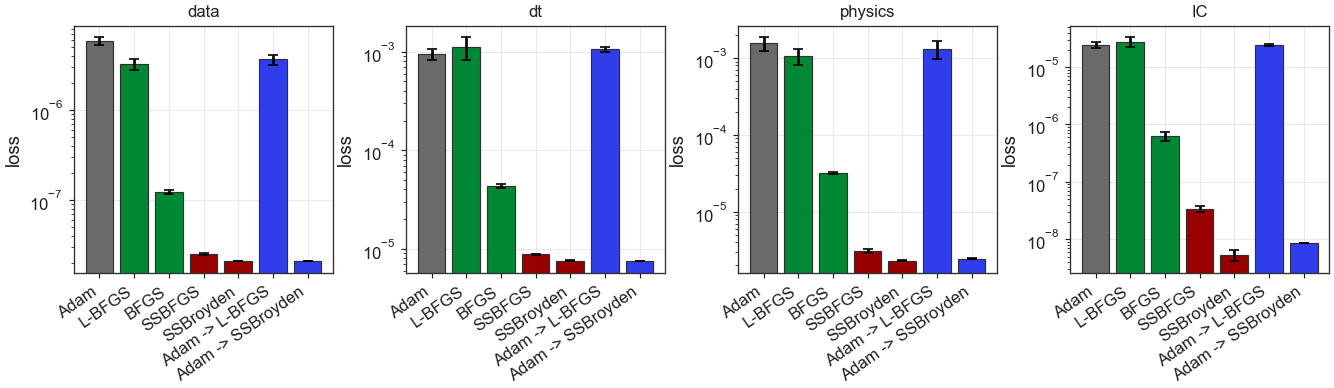

In [8]:
VAL_COMPONENTS = ["val_data_loss", "val_dt_loss", "val_physics_loss", "val_ic_loss", "val_total_loss"]

def final_validation_record(row):
    path = epoch_metrics_path(ROOT, row["batch"], row["run_name"])
    df = read_epoch_metrics(path)
    if df.empty or "val_total_loss" not in df.columns:
        return None
    val_rows = df[pd.to_numeric(df["val_total_loss"], errors="coerce").notna()].copy()
    if val_rows.empty:
        return None
    last = val_rows.iloc[-1]
    record = {
        "batch": row["batch"],
        "run_name": row["run_name"],
        "analysis_key": row["analysis_key"],
        "optimizer": row["optimizer_label"],
        "seed_label": row["seed_label"],
        "is_primary": bool(row["is_primary"]),
        "final_validation_epoch": last.get("global_epoch"),
        "final_validation_phase": last.get("phase_name"),
    }
    for component in VAL_COMPONENTS:
        record[component] = pd.to_numeric(pd.Series([last.get(component)]), errors="coerce").iloc[0]
    return record

val_records = [final_validation_record(row) for _, row in runs.iterrows()]
val_components = pd.DataFrame([row for row in val_records if row is not None])
# Scratch export disabled for repository submission; keep derived data in memory.
# val_components.to_csv(EXPORT / "final_validation_components_run_level.csv", index=False)
val_primary = val_components[val_components["is_primary"]].copy()
val_agg = aggregate_mean_sem(
    val_primary,
    group_cols="analysis_key",
    metrics=VAL_COMPONENTS,
    seed_col="seed_label",
    run_col="run_name",
    order_col="analysis_key",
    order=ANALYSIS_ORDER,
)
# Scratch export disabled for repository submission; keep derived data in memory.
# val_agg.to_csv(EXPORT / "final_validation_components_numeric.csv", index=False)

val_table = pd.DataFrame({
    "optimizer": val_agg["analysis_key"].astype(str).map(LABELS),
    "seeds": val_agg["seeds"],
    "val data": val_agg.apply(lambda row: mean_sem_text(row, "val_data_loss", decimals=2), axis=1),
    "val dt": val_agg.apply(lambda row: mean_sem_text(row, "val_dt_loss", decimals=2), axis=1),
    "val physics": val_agg.apply(lambda row: mean_sem_text(row, "val_physics_loss", decimals=2), axis=1),
    "val IC": val_agg.apply(lambda row: mean_sem_text(row, "val_ic_loss", decimals=2), axis=1),
    "val total": val_agg.apply(lambda row: mean_sem_text(row, "val_total_loss", decimals=2), axis=1),
})
# Scratch export disabled for repository submission; keep derived data in memory.
# val_table.to_csv(EXPORT / "final_validation_components_table.csv", index=False)
display(val_table)

component_specs = [
    ("val_data_loss", "data"),
    ("val_dt_loss", "dt"),
    ("val_physics_loss", "physics"),
    ("val_ic_loss", "IC"),
]
fig, axes = plt.subplots(1, len(component_specs), figsize=(13.5, 3.8), sharey=False)
for ax, (metric, title) in zip(axes, component_specs):
    x = np.arange(len(val_agg))
    colors = [optimizer_color(key) for key in val_agg["analysis_key"].astype(str)]
    ax.bar(x, val_agg[f"{metric}_mean"], yerr=np.nan_to_num(val_agg[f"{metric}_sem"], nan=0.0), capsize=3, color=colors, edgecolor=NEUTRAL_COLORS["axis"], linewidth=0.7)
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels([LABELS.get(str(key), str(key)) for key in val_agg["analysis_key"]], rotation=35, ha="right")
    ax.set_yscale("log")
    ax.set_ylabel("loss")
fig.subplots_adjust(wspace=0.28, bottom=0.34)
# Figure export disabled for repository submission; keep plot inline.
# fig.savefig(EXPORT / "optimizer_final_validation_components.png", dpi=300, bbox_inches="tight")
plt.show()


## Convergence Behavior


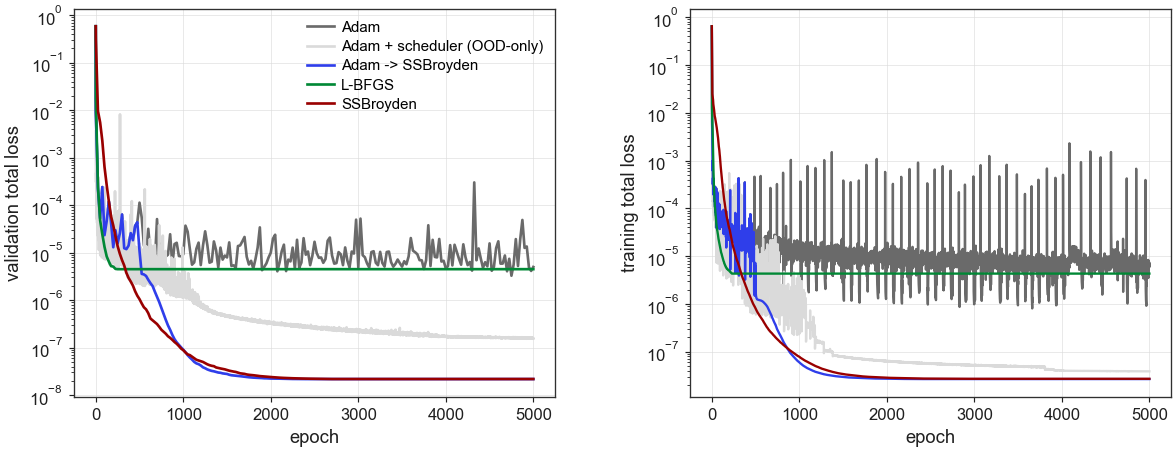

In [9]:
def convergence_frame_for(row):
    df = read_epoch_metrics(
        epoch_metrics_path(ROOT, row["batch"], row["run_name"]),
        columns=["global_epoch", "phase_name", "val_total_loss", "val_data_loss", "test_data_loss", "train_total_loss"],
    )
    if df.empty or "global_epoch" not in df.columns:
        return None
    df = df[df["global_epoch"].notna()].copy()
    df["analysis_key"] = str(row["analysis_key"])
    df["optimizer"] = row["optimizer_label"]
    df["seed_label"] = row["seed_label"]
    df["run_name"] = row["run_name"]
    return df

selected_rows = []
conv_source = runs[runs["analysis_key"].astype(str).isin(SELECTED_CONVERGENCE)].copy()
for key in SELECTED_CONVERGENCE:
    sub = conv_source[conv_source["analysis_key"].astype(str) == key]
    if sub.empty:
        continue
    selected_rows.append(sub[sub["seed_label"].astype(str) == "s01"].iloc[0] if (sub["seed_label"].astype(str) == "s01").any() else sub.iloc[0])
conv_parts = [convergence_frame_for(row) for row in selected_rows]
conv = pd.concat([part for part in conv_parts if part is not None], ignore_index=True) if conv_parts else pd.DataFrame()
# Scratch export disabled for repository submission; keep derived data in memory.
# conv.to_csv(EXPORT / "convergence_selected_runs.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(11.8, 4.2), sharex=True)
for key, sub in conv.groupby("analysis_key", observed=True):
    label = LABELS.get(str(key), str(key))
    color = optimizer_color(str(key))
    eval_rows = sub[sub["val_total_loss"].notna()]
    if not eval_rows.empty:
        axes[0].plot(eval_rows["global_epoch"], eval_rows["val_total_loss"], label=label, color=color, linewidth=1.6)
    train_rows = sub[sub["train_total_loss"].notna()]
    if not train_rows.empty:
        axes[1].plot(train_rows["global_epoch"], train_rows["train_total_loss"], label=label, color=color, linewidth=1.4)
axes[0].set_yscale("log")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("validation total loss")
axes[1].set_yscale("log")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("training total loss")
axes[0].legend()
fig.subplots_adjust(wspace=0.28)
# Figure export disabled for repository submission; keep plot inline.
# fig.savefig(EXPORT / "optimizer_convergence_selected.png", dpi=300, bbox_inches="tight")
plt.show()


## Convergence with Loss Decomposition

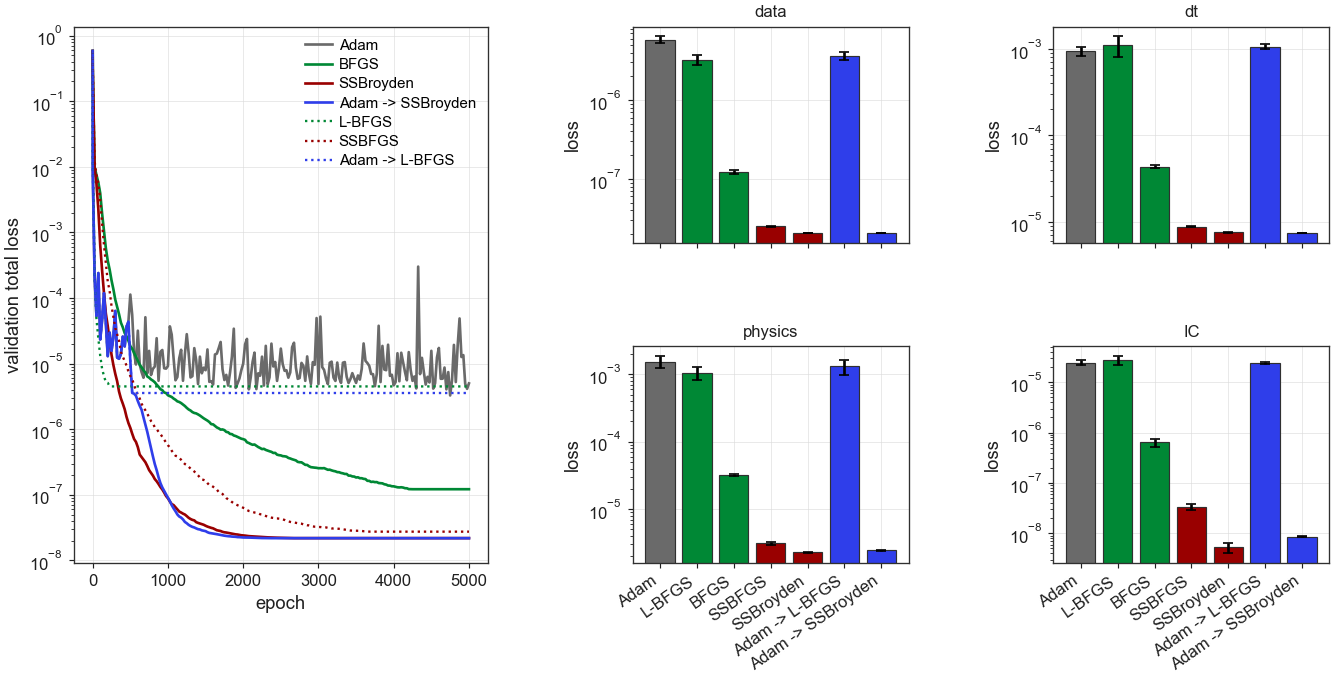

In [10]:
DECOMP_SPECS = [
    ("val_data_loss", "data"),
    ("val_dt_loss", "dt"),
    ("val_physics_loss", "physics"),
    ("val_ic_loss", "IC"),
]

SOLID_KEYS  = ["adam_no_scheduler", "bfgs", "ssbroyden", "adam_ssbroyden"]
DOTTED_KEYS = ["lbfgs", "ssbfgs", "adam_lbfgs"]


def load_convergence_s01(keys):
    rows = []
    for key in keys:
        sub = runs[runs["analysis_key"].astype(str) == key]
        if sub.empty:
            continue
        rows.append(
            sub[sub["seed_label"].astype(str) == "s01"].iloc[0]
            if (sub["seed_label"].astype(str) == "s01").any()
            else sub.iloc[0]
        )
    parts = [convergence_frame_for(row) for row in rows]
    out = (
        pd.concat([p for p in parts if p is not None], ignore_index=True)
        if any(p is not None for p in parts)
        else pd.DataFrame()
    )
    if not out.empty:
        out["analysis_key"] = pd.Categorical(
            out["analysis_key"].astype(str), categories=ANALYSIS_ORDER, ordered=True
        )
    return out


conv_solid  = load_convergence_s01(SOLID_KEYS)
conv_dotted = load_convergence_s01(DOTTED_KEYS)

fig, axes = plt.subplot_mosaic(
    [["total", "data", "dt"],
     ["total", "physics", "IC"]],
    figsize=(13.5, 5.8),
    gridspec_kw={"wspace": 0.45, "hspace": 0.48, "width_ratios": [1.5, 1, 1]},
)

# Left: validation total loss vs epoch
for opt_key, sub in conv_solid.groupby("analysis_key", observed=True):
    val_rows = sub[sub["val_total_loss"].notna()]
    if not val_rows.empty:
        axes["total"].plot(
            val_rows["global_epoch"], val_rows["val_total_loss"],
            label=LABELS.get(str(opt_key), str(opt_key)),
            color=optimizer_color(str(opt_key)),
            linewidth=1.6,
        )
for opt_key, sub in conv_dotted.groupby("analysis_key", observed=True):
    val_rows = sub[sub["val_total_loss"].notna()]
    if not val_rows.empty:
        axes["total"].plot(
            val_rows["global_epoch"], val_rows["val_total_loss"],
            label=LABELS.get(str(opt_key), str(opt_key)),
            color=optimizer_color(str(opt_key)),
            linewidth=1.4,
            linestyle=":",
        )
axes["total"].set_yscale("log")
axes["total"].set_xlabel("epoch")
axes["total"].set_ylabel("validation total loss")
axes["total"].legend()

# Right 2x2: final-epoch validation loss components (bar charts)
x = np.arange(len(val_agg))
xlabels = [LABELS.get(str(k), str(k)) for k in val_agg["analysis_key"]]
colors = [optimizer_color(k) for k in val_agg["analysis_key"].astype(str)]

for metric, panel in DECOMP_SPECS:
    ax = axes[panel]
    ax.bar(
        x,
        val_agg[f"{metric}_mean"],
        yerr=np.nan_to_num(val_agg[f"{metric}_sem"], nan=0.0),
        capsize=3,
        color=colors,
        edgecolor=NEUTRAL_COLORS["axis"],
        linewidth=0.7,
    )
    ax.set_title(panel)
    ax.set_xticks(x)
    ax.set_yscale("log")
    ax.set_ylabel("loss")

# X-tick labels only on bottom row
for panel in ["data", "dt"]:
    axes[panel].set_xticklabels([])
for panel in ["physics", "IC"]:
    axes[panel].set_xticklabels(xlabels, rotation=35, ha="right")

# Figure export disabled for repository submission; keep plot inline.
# fig.savefig(EXPORT / "optimizer_convergence_decomposition.png", dpi=300, bbox_inches="tight")
plt.show()

## Notes

The primary comparison excludes SOAP and the old Adam scheduler batch because they are not complete, comparable three-seed ID/OOD matrices. In the current complete set, SSBroyden is the strongest accuracy-runtime candidate: it provides the best OOD accuracy among the complete methods while remaining much faster than BFGS and SSBFGS. Hybrid Adam warmup is not automatically beneficial; Adam -> SSBroyden is strong in ID/test error, but pure SSBroyden generalizes better OOD in this result set.


## Final Validation Loss Decomposition

The table below reports final-epoch validation loss component magnitudes for the primary training methods, aggregated across seeds.

In [11]:
VAL_LOSS_COLUMNS = [
    "val_total_loss",
    "val_data_loss",
    "val_ic_loss",
    "val_dt_loss",
    "val_physics_loss",
]
VAL_LOSS_LABELS = [
    ("val_total_loss", "validation total loss"),
    ("val_data_loss", "validation data loss"),
    ("val_ic_loss", "validation IC loss"),
    ("val_dt_loss", "validation dt loss"),
    ("val_physics_loss", "validation physics loss"),
]

training_val_loss_rows = []
for _, run in primary.iterrows():
    path = epoch_metrics_path(ROOT, run["batch"], run["run_name"])
    epoch_frame = read_epoch_metrics(path, columns=["global_epoch", "phase_name", *VAL_LOSS_COLUMNS])
    if epoch_frame.empty or "global_epoch" not in epoch_frame.columns:
        continue
    epoch_frame = epoch_frame.dropna(subset=["global_epoch"]).copy()
    if epoch_frame.empty:
        continue
    final_epoch = int(pd.to_numeric(epoch_frame["global_epoch"], errors="coerce").max())
    final_rows = epoch_frame[pd.to_numeric(epoch_frame["global_epoch"], errors="coerce") == final_epoch]
    if final_rows.empty:
        continue
    final = final_rows.iloc[-1]
    training_val_loss_rows.append({
        "batch": run["batch"],
        "run_name": run["run_name"],
        "analysis_key": run["analysis_key"],
        "optimizer": LABELS.get(str(run["analysis_key"]), str(run["analysis_key"])),
        "family": FAMILY.get(str(run["analysis_key"]), "other"),
        "seed_label": run["seed_label"],
        "final_epoch": final_epoch,
        "final_phase": final.get("phase_name", np.nan),
        **{metric: final.get(metric, np.nan) for metric in VAL_LOSS_COLUMNS},
    })

training_final_val_losses = pd.DataFrame(training_val_loss_rows)
if training_final_val_losses.empty:
    raise FileNotFoundError("No final validation loss rows could be read from epoch_metrics.csv files.")
training_final_val_losses["analysis_key"] = pd.Categorical(
    training_final_val_losses["analysis_key"].astype(str), categories=ANALYSIS_ORDER, ordered=True
)
training_final_val_losses = training_final_val_losses.sort_values(["analysis_key", "seed_label"]).reset_index(drop=True)
# Scratch export disabled for repository submission; keep derived data in memory.
# training_final_val_losses.to_csv(EXPORT / "training_methods_final_validation_losses_run_level.csv", index=False)

training_final_val_loss_numeric = aggregate_mean_sem(
    training_final_val_losses,
    group_cols="analysis_key",
    metrics=["final_epoch", *VAL_LOSS_COLUMNS],
    seed_col="seed_label",
    run_col="run_name",
    order_col="analysis_key",
    order=ANALYSIS_ORDER,
)
# Scratch export disabled for repository submission; keep derived data in memory.
# training_final_val_loss_numeric.to_csv(EXPORT / "training_methods_final_validation_losses_table_numeric.csv", index=False)

rows = []
for _, row in training_final_val_loss_numeric.iterrows():
    key = str(row["analysis_key"])
    record = {
        "Training method": LABELS.get(key, key),
        "Family": FAMILY.get(key, "other"),
        "Seeds": row.get("seeds", ""),
        "final epoch": mean_sem_text(row, "final_epoch", decimals=0, scientific=False),
    }
    for metric, label in VAL_LOSS_LABELS:
        record[label] = mean_sem_text(row, metric, decimals=2, scientific=True)
    rows.append(record)

training_final_val_loss_table = pd.DataFrame(rows)
# Scratch export disabled for repository submission; keep derived data in memory.
# training_final_val_loss_table.to_csv(EXPORT / "training_methods_final_validation_losses_table.csv", index=False)
display(training_final_val_loss_table)


,Training method,Family,Seeds,final epoch,validation total loss,validation data loss,validation IC loss,validation dt loss,validation physics loss
0,Adam,first-order,"s01,s02,s03",5000 +/- 0,6.11e-06 +/- 5.83e-07,5.84e-06 +/- 5.75e-07,2.44e-05 +/- 2.91e-06,9.42e-04 +/- 1.21e-04,1.54e-03 +/- 3.04e-04
1,L-BFGS,quasi-Newton,"s01,s02,s03",5000 +/- 0,3.51e-06 +/- 5.35e-07,3.26e-06 +/- 4.80e-07,2.75e-05 +/- 5.25e-06,1.10e-03 +/- 2.88e-04,1.05e-03 +/- 2.45e-04
2,BFGS,quasi-Newton,"s01,s02,s03",5000 +/- 0,1.30e-07 +/- 6.12e-09,1.22e-07 +/- 5.99e-09,6.36e-07 +/- 1.14e-07,4.35e-05 +/- 1.60e-06,3.19e-05 +/- 7.65e-07
3,SSBFGS,self-scaled quasi-Newton,"s01,s02,s03",5000 +/- 0,2.64e-08 +/- 5.39e-10,2.51e-08 +/- 5.18e-10,3.34e-08 +/- 4.04e-09,8.79e-06 +/- 9.69e-08,3.11e-06 +/- 1.78e-07
4,SSBroyden,self-scaled quasi-Newton,"s01,s02,s03",5000 +/- 0,2.18e-08 +/- 4.95e-11,2.08e-08 +/- 3.94e-11,5.26e-09 +/- 1.13e-09,7.56e-06 +/- 8.30e-08,2.29e-06 +/- 3.09e-08
5,Adam -> L-BFGS,hybrid,"s01,s02,s03",5000 +/- 0,3.92e-06 +/- 4.88e-07,3.66e-06 +/- 4.52e-07,2.38e-05 +/- 9.47e-07,1.06e-03 +/- 7.18e-05,1.31e-03 +/- 3.41e-04
6,Adam -> SSBroyden,hybrid,"s01,s02,s03",5000 +/- 0,2.18e-08 +/- 8.51e-11,2.08e-08 +/- 8.30e-11,8.64e-09 +/- 6.23e-11,7.51e-06 +/- 3.73e-08,2.45e-06 +/- 5.64e-08
